# Diabetes Ensemble-Learning

## 1. Install and import

In [ ]:
!pip install -q xgboost lightgbm catboost imbalanced-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              average_precision_score)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Imports OK")

Imports OK


## 2. Load your data from Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
df_pima_indians_diabetes = pd.read_csv('/content/gdrive/MyDrive/ColabNotebooks/Evaluation_of_Diabetes/1. pima_indians_diabetes.csv')
df_frankfurt_diabetes = pd.read_csv('/content/gdrive/MyDrive/ColabNotebooks/Evaluation_of_Diabetes/2. frankfurt_diabetes.csv')
df_sylhet_diabetes = pd.read_csv('/content/gdrive/MyDrive/ColabNotebooks/Evaluation_of_Diabetes/3. sylhet_diabetes.csv')

RAW_DATAFRAMES = {
    "PID": df_pima_indians_diabetes,
    "Frankfurt": df_frankfurt_diabetes,
    "Sylhet": df_sylhet_diabetes,
}
print("Loaded:", {k: v.shape for k, v in RAW_DATAFRAMES.items()})

Loaded: {'PID': (768, 9), 'Frankfurt': (2000, 9), 'Sylhet': (520, 17)}


## 3. Model definitions

In [ ]:
def build_models(seed):
    """Models matching the manuscript's hyperparameter table (Table 5),
    with random_state fixed for reproducibility."""
    models = {
        "Bagging": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=None, random_state=seed),
            n_estimators=100, random_state=seed),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_split=2, random_state=seed),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=200, max_depth=12, min_samples_split=2, random_state=seed),
        "AdaBoost": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=seed),
            n_estimators=100, learning_rate=0.1, random_state=seed),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.1, random_state=seed),
        "Extreme Gradient Boosting": XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.8,
            random_state=seed, eval_metric="logloss"),
        "Light Gradient Boosting": LGBMClassifier(
            n_estimators=200, num_leaves=31, learning_rate=0.1,
            random_state=seed, verbosity=-1),
        "Cat Boosting": CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1,
            random_state=seed, verbose=False),
        "Stacking": StackingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=2000, random_state=seed)),
                ("svm", SVC(probability=True, random_state=seed)),
                ("bayes", GaussianNB()),
                ("knn", KNeighborsClassifier()),
                ("cart", DecisionTreeClassifier(random_state=seed)),
            ],
            final_estimator=LogisticRegression(penalty="l2", C=1.0, random_state=seed, max_iter=2000),
        ),
    }
    return models


def load_dataset(name):
    if name == "PID":
        df = RAW_DATAFRAMES["PID"]
        X = df.iloc[:, :8]
        y = df["Outcome"].values
    elif name == "Frankfurt":
        df = RAW_DATAFRAMES["Frankfurt"]
        X = df.iloc[:, :8]
        y = df["Outcome"].values
    elif name == "Sylhet":
        df = RAW_DATAFRAMES["Sylhet"]
        X = df.iloc[:, :16]
        y = df["class"].map({"Positive": 1, "Negative": 0}).astype(int).values
        X = pd.get_dummies(X)
    else:
        raise ValueError(name)
    scaler = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y


def evaluate(y_true, y_pred, y_score=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if y_score is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
        out["pr_auc"] = average_precision_score(y_true, y_score)
    return out

DATASETS = ["PID", "Frankfurt", "Sylhet"]
print("Definitions OK")

Definitions OK


## 4. Main hold-out run (seed=42): accuracy/precision/recall/F1, ROC-AUC, PR-AUC, confusion matrices, specificity/sensitivity

SMOTE is applied only to the training fold, after the stratified 80/20 split, to prevent leakage.

In [ ]:
main_rows = []
confusion_matrices = {}
predictions_store = {}  # (dataset, model) -> dict(y_test, y_pred, y_score)
MAIN_SEED = 42

for dataset in DATASETS:
    X, y = load_dataset(dataset)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=MAIN_SEED, stratify=y)
    sm = SMOTE(random_state=MAIN_SEED)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

    models = build_models(MAIN_SEED)
    for model_name, model in models.items():
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)
        y_score = (model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba")
                   else model.decision_function(X_test))
        metrics = evaluate(y_test, y_pred, y_score)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        confusion_matrices[(dataset, model_name)] = cm
        predictions_store[(dataset, model_name)] = {"y_test": y_test, "y_pred": y_pred, "y_score": y_score}
        row = {"dataset": dataset, "model": model_name, **metrics,
               "tn": tn, "fp": fp, "fn": fn, "tp": tp,
               "specificity": tn / (tn + fp), "sensitivity_recall": tp / (tp + fn)}
        main_rows.append(row)
        print(f"[{dataset}] {model_name}: acc={metrics['accuracy']:.4f} prec={metrics['precision']:.4f} "
              f"rec={metrics['recall']:.4f} f1={metrics['f1']:.4f} roc_auc={metrics['roc_auc']:.4f} "
              f"pr_auc={metrics['pr_auc']:.4f}")

main_df = pd.DataFrame(main_rows)
main_df.to_csv(f"{RESULTS_DIR}/main_holdout_results_seed42.csv", index=False)
main_df

[PID] Bagging: acc=0.7338 prec=0.7103 rec=0.7183 f1=0.7135 roc_auc=0.8100 pr_auc=0.6732
[PID] Random Forest: acc=0.7468 prec=0.7271 rec=0.7411 f1=0.7312 roc_auc=0.8196 pr_auc=0.6790
[PID] Extra Trees: acc=0.7532 prec=0.7330 rec=0.7461 f1=0.7372 roc_auc=0.8120 pr_auc=0.6653
[PID] AdaBoost: acc=0.7403 prec=0.7315 rec=0.7531 f1=0.7314 roc_auc=0.8275 pr_auc=0.6514
[PID] Gradient Boosting: acc=0.7338 prec=0.7137 rec=0.7269 f1=0.7175 roc_auc=0.8157 pr_auc=0.6901
[PID] Extreme Gradient Boosting: acc=0.7403 prec=0.7235 rec=0.7404 f1=0.7270 roc_auc=0.8187 pr_auc=0.6826


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[PID] Light Gradient Boosting: acc=0.7597 prec=0.7378 rec=0.7469 f1=0.7414 roc_auc=0.8181 pr_auc=0.6773
[PID] Cat Boosting: acc=0.7403 prec=0.7195 rec=0.7319 f1=0.7234 roc_auc=0.8222 pr_auc=0.7089
[PID] Stacking: acc=0.6948 prec=0.6734 rec=0.6841 f1=0.6761 roc_auc=0.7765 pr_auc=0.6473
[Frankfurt] Bagging: acc=0.9850 prec=0.9833 rec=0.9833 f1=0.9833 roc_auc=0.9978 pr_auc=0.9962
[Frankfurt] Random Forest: acc=0.9700 prec=0.9639 rec=0.9702 f1=0.9669 roc_auc=0.9953 pr_auc=0.9920
[Frankfurt] Extra Trees: acc=0.9625 prec=0.9577 rec=0.9592 f1=0.9584 roc_auc=0.9928 pr_auc=0.9869
[Frankfurt] AdaBoost: acc=0.8025 prec=0.7839 rec=0.8061 f1=0.7902 roc_auc=0.8984 pr_auc=0.8202
[Frankfurt] Gradient Boosting: acc=0.9350 prec=0.9278 rec=0.9278 f1=0.9278 roc_auc=0.9838 pr_auc=0.9734
[Frankfurt] Extreme Gradient Boosting: acc=0.9050 prec=0.8913 rec=0.9015 f1=0.8959 roc_auc=0.9650 pr_auc=0.9436


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Frankfurt] Light Gradient Boosting: acc=0.9850 prec=0.9833 rec=0.9833 f1=0.9833 roc_auc=0.9894 pr_auc=0.9895
[Frankfurt] Cat Boosting: acc=0.9775 prec=0.9743 rec=0.9759 f1=0.9751 roc_auc=0.9902 pr_auc=0.9829
[Frankfurt] Stacking: acc=0.9750 prec=0.9694 rec=0.9757 f1=0.9724 roc_auc=0.9904 pr_auc=0.9884
[Sylhet] Bagging: acc=0.9904 prec=0.9878 rec=0.9922 f1=0.9899 roc_auc=0.9982 pr_auc=0.9989
[Sylhet] Random Forest: acc=0.9904 prec=0.9878 rec=0.9922 f1=0.9899 roc_auc=1.0000 pr_auc=1.0000
[Sylhet] Extra Trees: acc=0.9904 prec=0.9923 rec=0.9875 f1=0.9898 roc_auc=0.9992 pr_auc=0.9995
[Sylhet] AdaBoost: acc=0.9615 prec=0.9545 rec=0.9688 f1=0.9601 roc_auc=0.9910 pr_auc=0.9959
[Sylhet] Gradient Boosting: acc=0.9904 prec=0.9878 rec=0.9922 f1=0.9899 roc_auc=0.9949 pr_auc=0.9974
[Sylhet] Extreme Gradient Boosting: acc=0.9808 prec=0.9762 rec=0.9844 f1=0.9799 roc_auc=1.0000 pr_auc=1.0000
[Sylhet] Light Gradient Boosting: acc=0.9808 prec=0.9762 rec=0.9844 f1=0.9799 roc_auc=1.0000 pr_auc=1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Sylhet] Cat Boosting: acc=0.9808 prec=0.9762 rec=0.9844 f1=0.9799 roc_auc=1.0000 pr_auc=1.0000
[Sylhet] Stacking: acc=0.9712 prec=0.9677 rec=0.9719 f1=0.9697 roc_auc=0.9992 pr_auc=0.9995


,dataset,model,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,specificity,sensitivity_recall
0,PID,Bagging,0.733766,0.710348,0.718333,0.713456,0.810000,0.673228,77,23,18,36,0.770000,0.666667
1,PID,Random Forest,0.746753,0.727106,0.741111,0.731239,0.819630,0.679029,76,24,15,39,0.760000,0.722222
2,PID,Extra Trees,0.753247,0.732994,0.746111,0.737249,0.812037,0.665313,77,23,15,39,0.770000,0.722222
3,PID,AdaBoost,0.740260,0.731538,0.753148,0.731380,0.827500,0.651383,71,29,11,43,0.710000,0.796296
4,PID,Gradient Boosting,0.733766,0.713675,0.726852,0.717456,0.815741,0.690111,75,25,16,38,0.750000,0.703704
5,PID,Extreme Gradient Boosting,0.740260,0.723485,0.740370,0.726950,0.818704,0.682599,74,26,14,40,0.740000,0.740741
6,PID,Light Gradient Boosting,0.759740,0.737823,0.746852,0.741411,0.818148,0.677268,79,21,16,38,0.790000,0.703704
7,PID,Cat Boosting,0.740260,0.719495,0.731852,0.723420,0.822222,0.708894,76,24,16,38,0.760000,0.703704
8,PID,Stacking,0.694805,0.673382,0.684074,0.676109,0.776481,0.647306,72,28,19,35,0.720000,0.648148
9,Frankfurt,Bagging,0.985000,0.983348,0.983348,0.983348,0.997835,0.996235,260,3,3,134,0.988593,0.978102


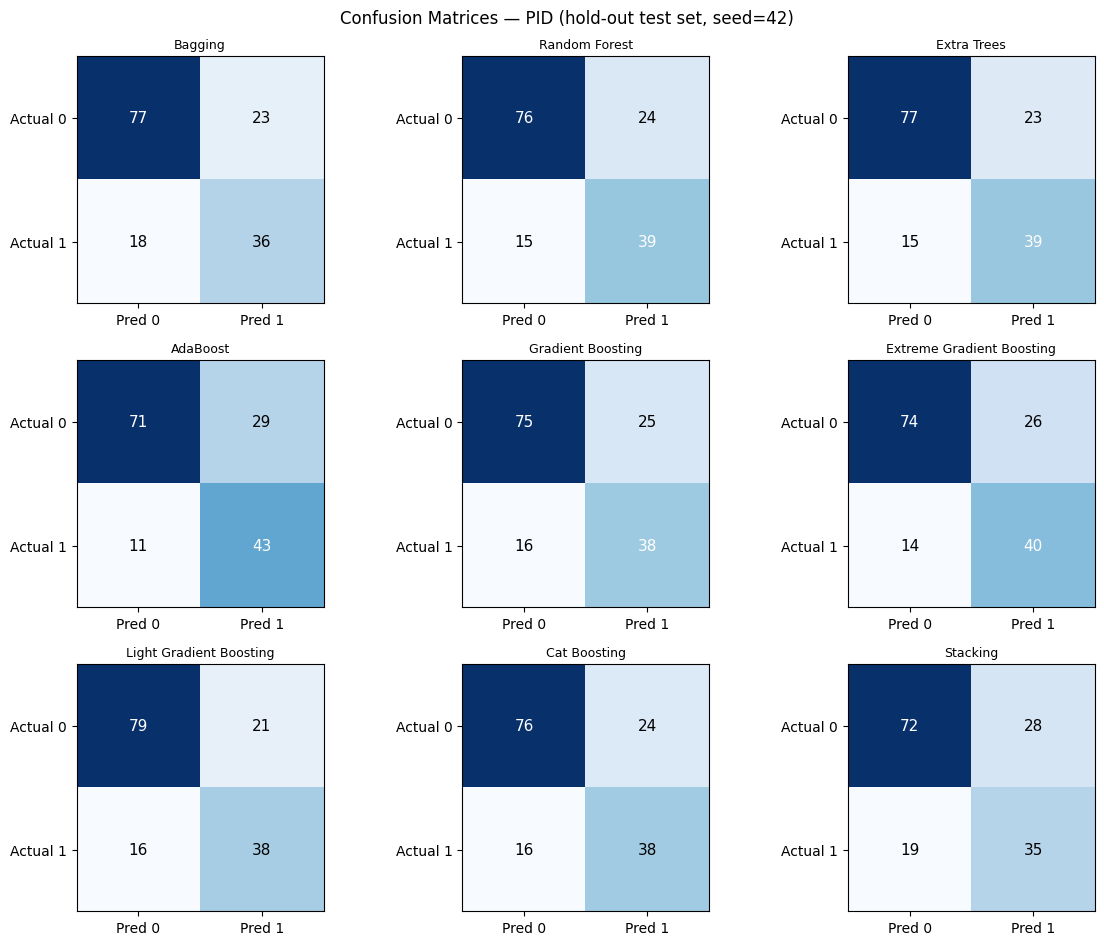

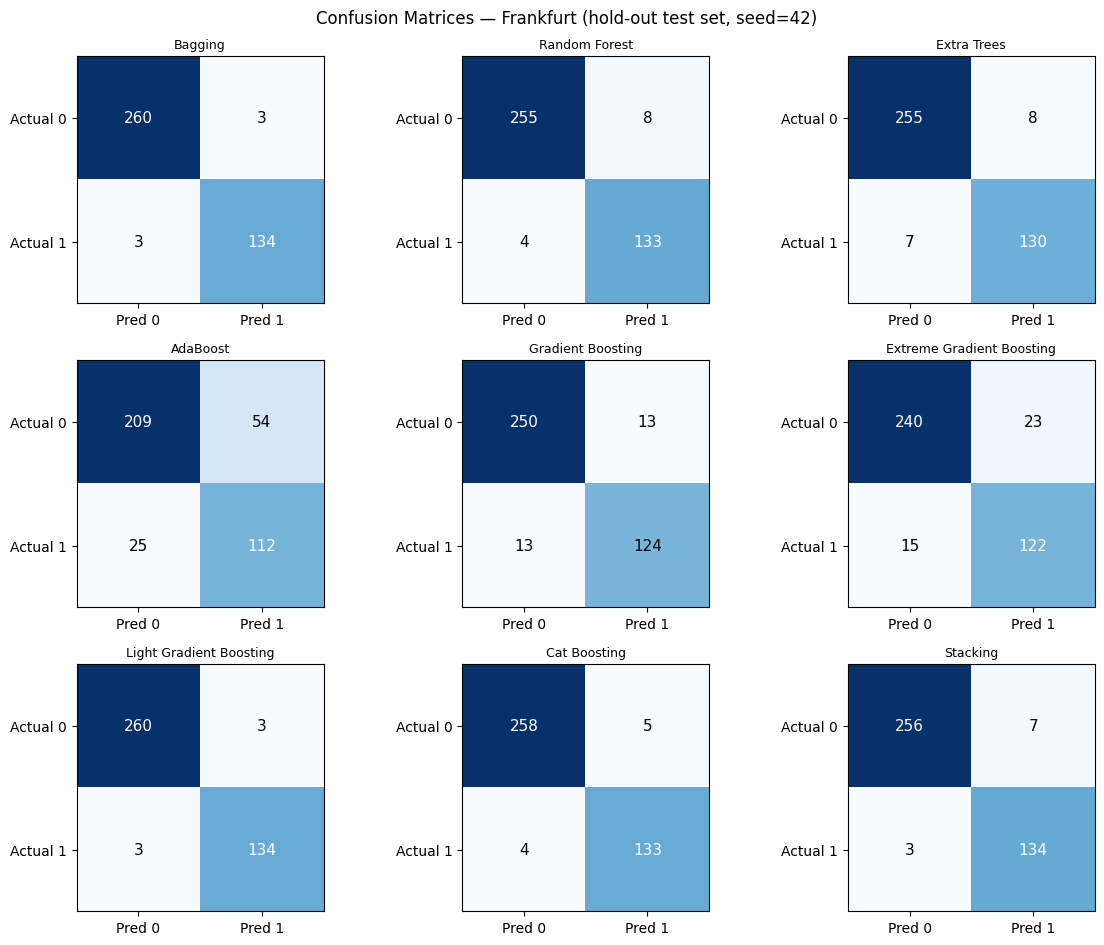

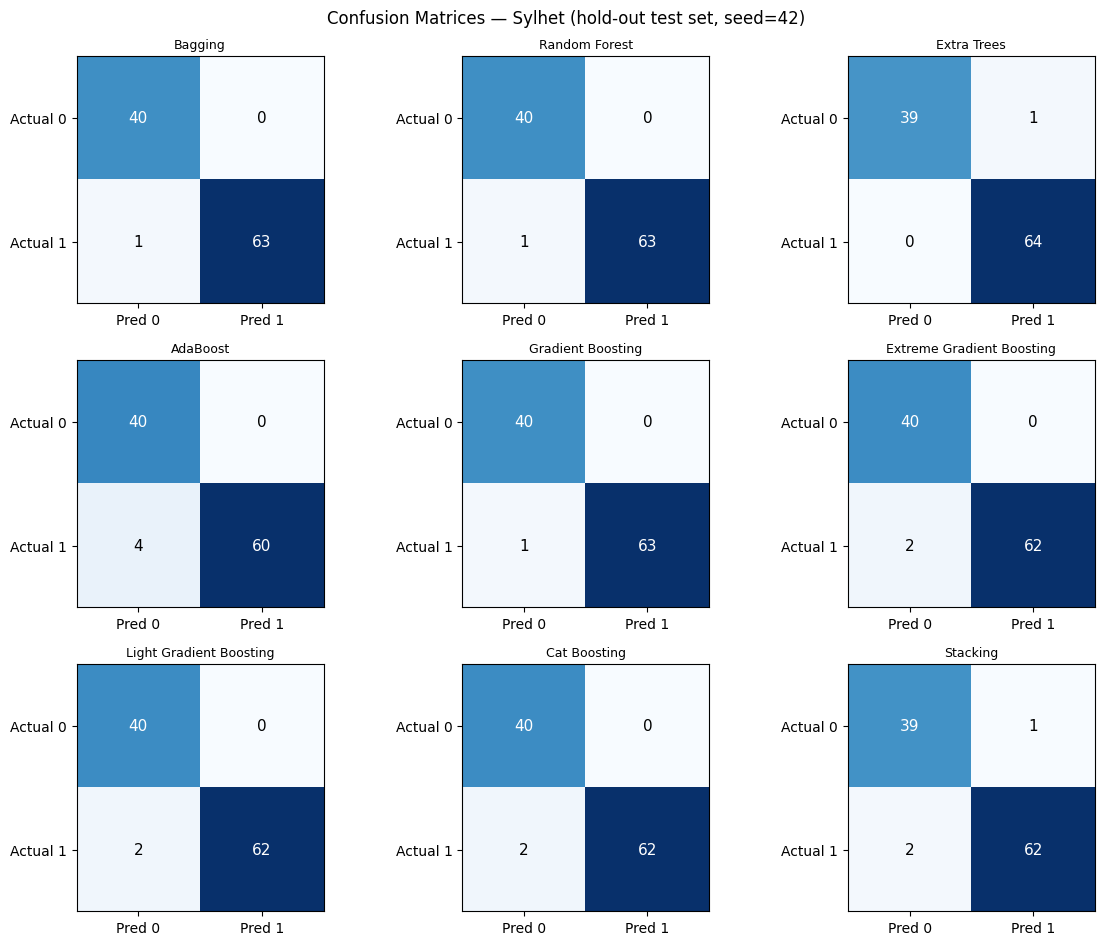

In [ ]:
# Confusion matrix figures (one grid per dataset)
for dataset in DATASETS:
    sub = main_df[main_df["dataset"] == dataset]
    n = len(sub)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sub.iterrows()):
        cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
        im = ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                        color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=11)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual 0", "Actual 1"])
        ax.set_title(row.model, fontsize=9)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"Confusion Matrices — {dataset} (hold-out test set, seed=42)")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/confusion_matrices_{dataset}.png", dpi=150)
    plt.show()

## 5. Random-state robustness: 10 independently seeded hold-out splits (mean ± SD, 95% CI)

In [ ]:
from scipy import stats

SEEDS = list(range(10))
robust_rows = []
for dataset in DATASETS:
    X, y = load_dataset(dataset)
    for seed in SEEDS:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.20, random_state=seed, stratify=y)
        sm = SMOTE(random_state=seed)
        X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
        models = build_models(seed)
        for model_name, model in models.items():
            model.fit(X_train_sm, y_train_sm)
            y_pred = model.predict(X_test)
            y_score = (model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba")
                       else model.decision_function(X_test))
            metrics = evaluate(y_test, y_pred, y_score)
            robust_rows.append({"dataset": dataset, "model": model_name, "seed": seed, **metrics})

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv(f"{RESULTS_DIR}/random_seed_robustness_raw.csv", index=False)

t_crit = stats.t.ppf(0.975, df=len(SEEDS) - 1)
def summarize(g):
    mean = g.mean()
    sd = g.std()
    se = sd / np.sqrt(len(g))
    return pd.Series({"mean": mean, "sd": sd, "ci_low": mean - t_crit * se, "ci_high": mean + t_crit * se})

summary = robust_df.groupby(["dataset", "model"])["accuracy"].apply(summarize).unstack()
summary.to_csv(f"{RESULTS_DIR}/random_seed_robustness_summary.csv")
summary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

mean        sd    ci_low   ci_high
dataset   model                                                            
Frankfurt AdaBoost                   0.785500  0.012517  0.776546  0.794454
          Bagging                    0.977750  0.010304  0.970379  0.985121
          Cat Boosting               0.965750  0.013897  0.955809  0.975691
          Extra Trees                0.952500  0.009718  0.945548  0.959452
          Extreme Gradient Boosting  0.885750  0.016161  0.874189  0.897311
          Gradient Boosting          0.898250  0.013897  0.888309  0.908191
          Light Gradient Boosting    0.974000  0.010685  0.966356  0.981644
          Random Forest              0.952000  0.007435  0.946681  0.957319
          Stacking                   0.974500  0.012405  0.965626  0.983374
PID       AdaBoost                   0.748701  0.050396  0.712650  0.784753
          Bagging                    0.747403  0.038895  0.719579  0.775226
          Cat Boosting               0.735714  0.036483  0.709616  0.761813
          Extra Trees                0.749351  0.043849  0.717983  0.780718
          Extreme Gradient Boosting  0.730519  0.038991  0.702627  0.758412
          Gradient Boosting          0.741558  0.044232  0.709917  0.773200
          Light Gradient Boosting    0.735714  0.032403  0.712535  0.758894
          Random Forest              0.755195  0.039564  0.726893  0.783497
          Stacking                   0.742208  0.039326  0.714076  0.770340
Sylhet    AdaBoost                   0.947115  0.019364  0.933263  0.960967
          Bagging                    0.985577  0.012205  0.976846  0.994308
          Cat Boosting               0.988462  0.012659  0.979406  0.997517
          Extra Trees                0.985577  0.011332  0.977471  0.993683
          Extreme Gradient Boosting  0.985577  0.013019  0.976263  0.994890
          Gradient Boosting          0.982692  0.013446  0.973073  0.992311
          Light Gradient Boosting    0.985577  0.010386  0.978147  0.993006
          Random Forest              0.978846  0.015570  0.967708  0.989985
          Stacking                   0.975000  0.015832  0.963674  0.986326

## 6. Stratified 5-fold cross-validation (SMOTE re-applied inside each fold)

In [ ]:
cv_rows = []
K = 5
for dataset in DATASETS:
    X, y = load_dataset(dataset)
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.20, random_state=MAIN_SEED, stratify=y)
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=MAIN_SEED)
    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        X_tr, X_val = X_train_full[tr_idx], X_train_full[val_idx]
        y_tr, y_val = y_train_full[tr_idx], y_train_full[val_idx]
        sm = SMOTE(random_state=MAIN_SEED)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)
        models = build_models(MAIN_SEED)
        for model_name, model in models.items():
            model.fit(X_tr_sm, y_tr_sm)
            y_pred = model.predict(X_val)
            metrics = evaluate(y_val, y_pred)
            cv_rows.append({"dataset": dataset, "model": model_name, "fold": fold_idx, **metrics})

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(f"{RESULTS_DIR}/cv_k5_raw.csv", index=False)
cv_summary = cv_df.groupby(["dataset", "model"]).agg(
    accuracy_mean=("accuracy", "mean"), accuracy_sd=("accuracy", "std"),
    f1_mean=("f1", "mean"), f1_sd=("f1", "std"),
).reset_index()
cv_summary.to_csv(f"{RESULTS_DIR}/cv_k5_summary.csv", index=False)
cv_summary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,dataset,model,accuracy_mean,accuracy_sd,f1_mean,f1_sd
0,Frankfurt,AdaBoost,0.783750,0.027635,0.771973,0.029160
1,Frankfurt,Bagging,0.945000,0.018302,0.939353,0.020651
2,Frankfurt,Cat Boosting,0.946250,0.015996,0.940638,0.017938
3,Frankfurt,Extra Trees,0.936250,0.011397,0.929416,0.013121
4,Frankfurt,Extreme Gradient Boosting,0.875625,0.016298,0.864448,0.018567
5,Frankfurt,Gradient Boosting,0.883750,0.020180,0.873541,0.022665
6,Frankfurt,Light Gradient Boosting,0.950000,0.009632,0.944895,0.010643
7,Frankfurt,Random Forest,0.931250,0.020010,0.924782,0.021854
8,Frankfurt,Stacking,0.936875,0.014218,0.929997,0.016043
9,PID,AdaBoost,0.767093,0.040941,0.750593,0.040372


## 7. Receiver Operating Characteristic (ROC) Curves for 3 datasets

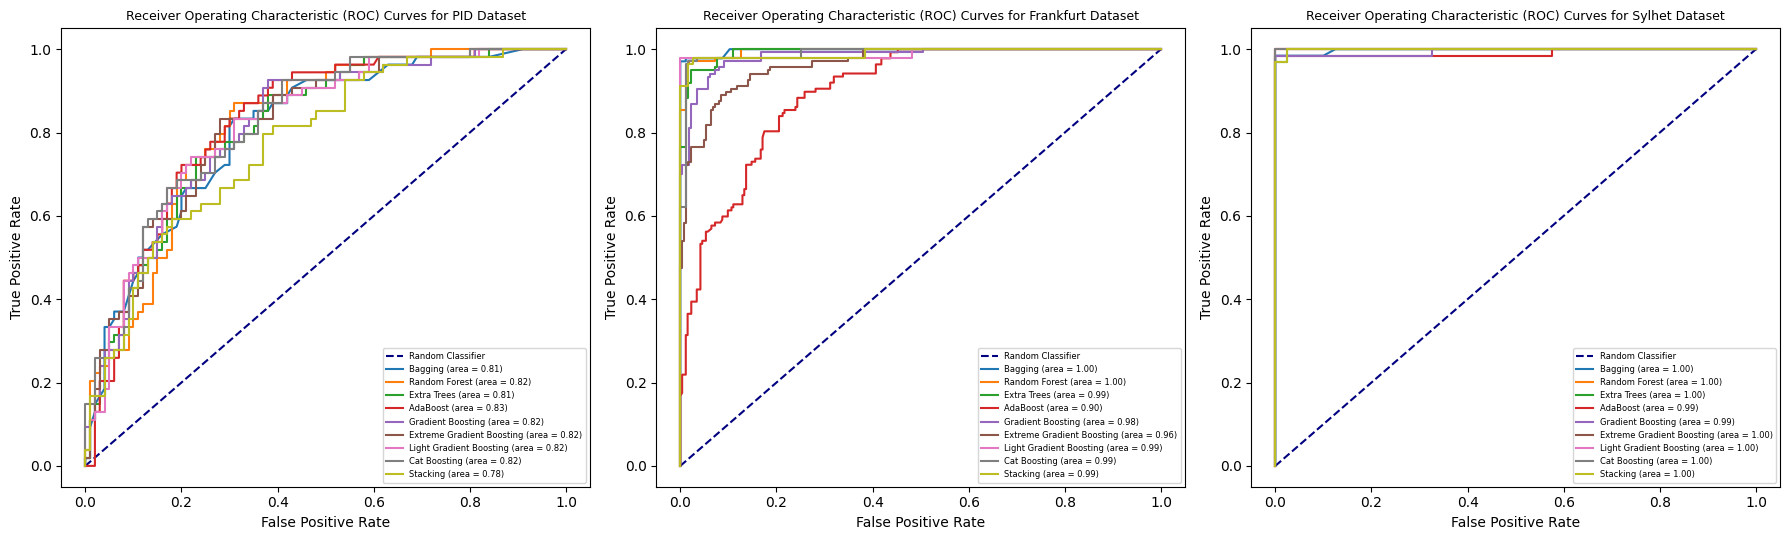

In [ ]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, dataset in zip(axes, DATASETS):
    ax.plot([0, 1], [0, 1], linestyle="--", color="navy", label="Random Classifier")
    for model_name in main_df[main_df["dataset"] == dataset]["model"]:
        pred = predictions_store[(dataset, model_name)]
        fpr, tpr, _ = roc_curve(pred["y_test"], pred["y_score"])
        auc = roc_auc_score(pred["y_test"], pred["y_score"])
        ax.plot(fpr, tpr, label=f"{model_name} (area = {auc:.2f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Receiver Operating Characteristic (ROC) Curves for {dataset} Dataset", fontsize=9)
    ax.legend(fontsize=6, loc="lower right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/roc_curves_3_datasets.png", dpi=150)
plt.show()

## 8. Calibration Curves (Reliability Diagrams) for 3 datasets

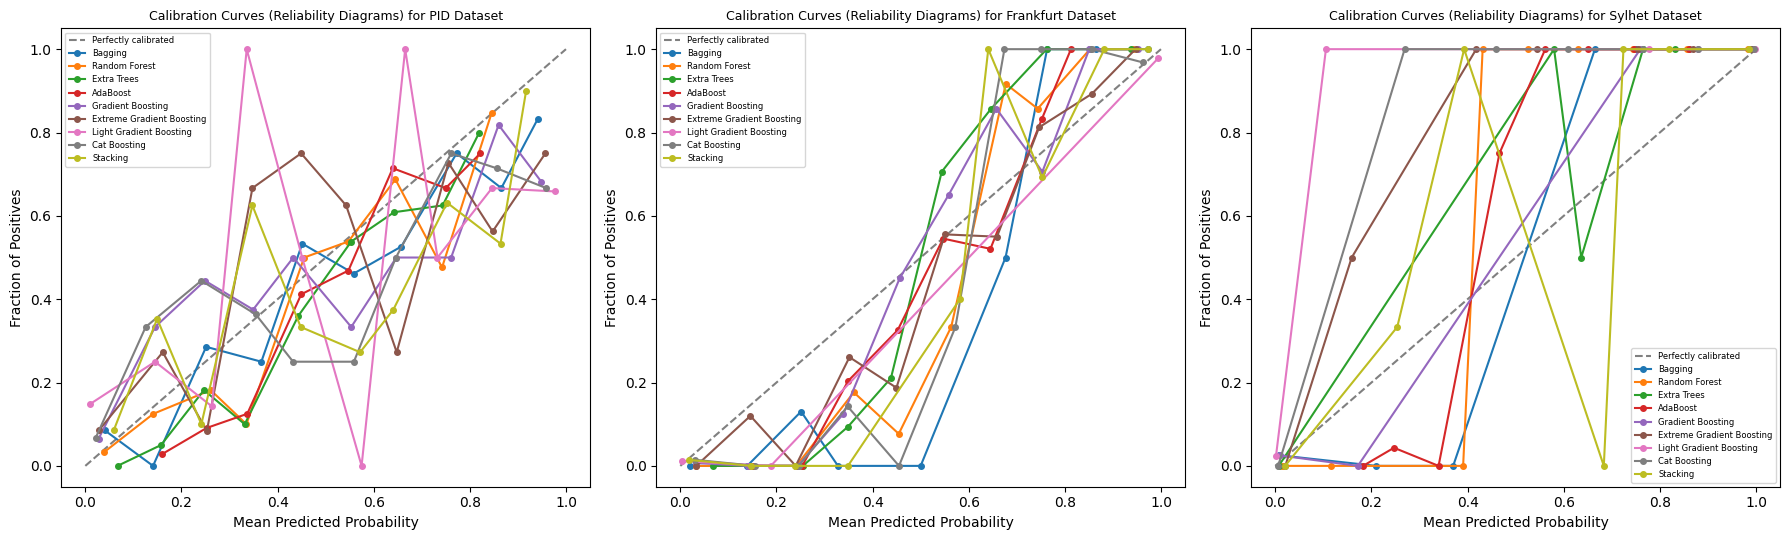

In [ ]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, dataset in zip(axes, DATASETS):
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
    for model_name in main_df[main_df["dataset"] == dataset]["model"]:
        pred = predictions_store[(dataset, model_name)]
        frac_pos, mean_pred = calibration_curve(pred["y_test"], pred["y_score"], n_bins=10, strategy="uniform")
        ax.plot(mean_pred, frac_pos, marker="o", markersize=4, label=model_name)
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"Calibration Curves (Reliability Diagrams) for {dataset} Dataset", fontsize=9)
    ax.legend(fontsize=6, loc="best")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/calibration_curves_3_datasets.png", dpi=150)
plt.show()

## 9. Pairwise McNemar's Test p-values for 3 datasets

For each pair of models on the same dataset, McNemar's test compares their hold-out predictions
on the identical test set (paired, since both models are evaluated on the same samples), testing
whether the two classifiers' disagreements are symmetric (i.e., whether one model is significantly
more accurate than the other).

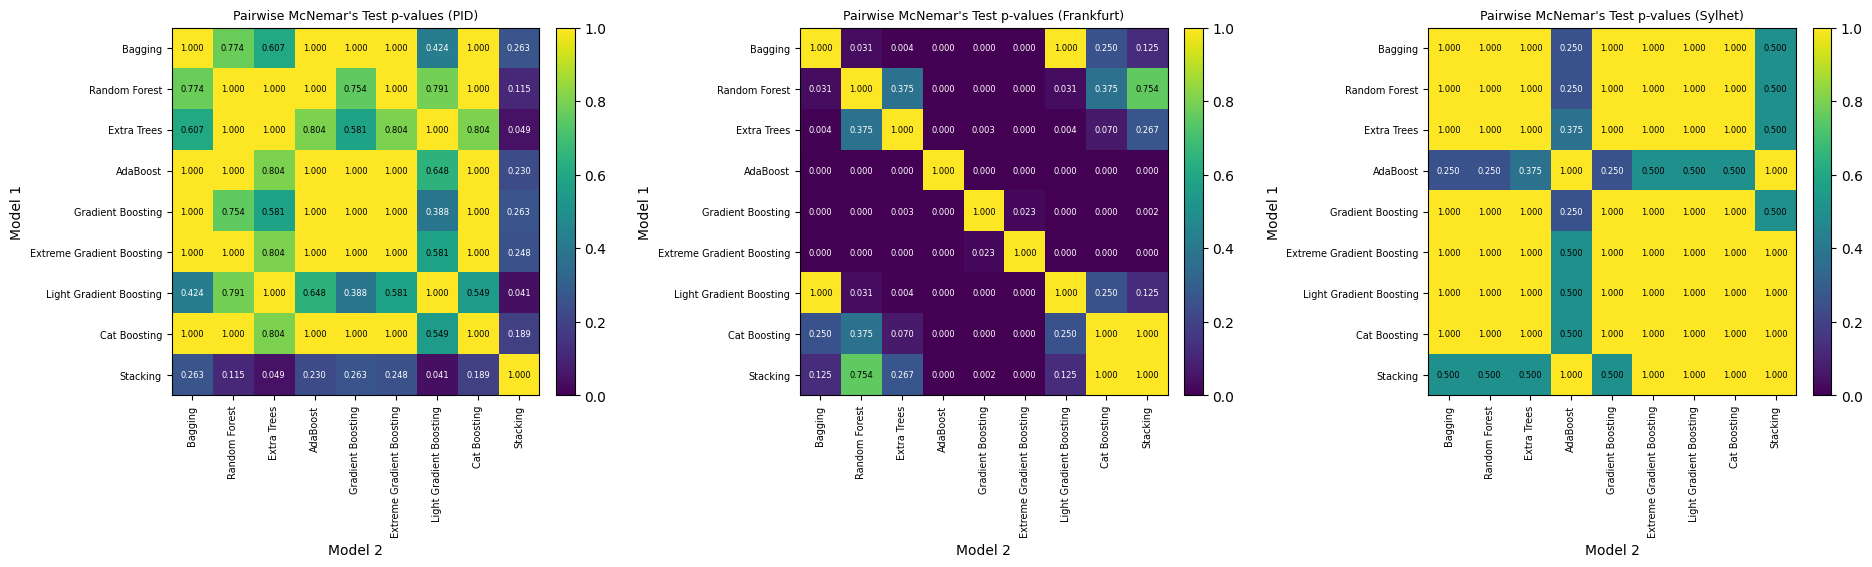

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
mcnemar_tables = {}
for ax, dataset in zip(axes, DATASETS):
    models_list = list(main_df[main_df["dataset"] == dataset]["model"])
    n = len(models_list)
    pvals = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            pi = predictions_store[(dataset, models_list[i])]
            pj = predictions_store[(dataset, models_list[j])]
            correct_i = (pi["y_pred"] == pi["y_test"])
            correct_j = (pj["y_pred"] == pj["y_test"])
            b = np.sum(correct_i & ~correct_j)   # i correct, j wrong
            c = np.sum(~correct_i & correct_j)   # i wrong, j correct
            table = [[np.sum(correct_i & correct_j), b], [c, np.sum(~correct_i & ~correct_j)]]
            result = mcnemar(table, exact=(b + c < 25), correction=True)
            pvals[i, j] = result.pvalue
    mcnemar_tables[dataset] = pd.DataFrame(pvals, index=models_list, columns=models_list)

    im = ax.imshow(pvals, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(models_list, rotation=90, fontsize=7)
    ax.set_yticks(range(n)); ax.set_yticklabels(models_list, fontsize=7)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{pvals[i, j]:.3f}", ha="center", va="center",
                    color="white" if pvals[i, j] < 0.5 else "black", fontsize=6)
    ax.set_title(f"Pairwise McNemar's Test p-values ({dataset})", fontsize=9)
    ax.set_xlabel("Model 2"); ax.set_ylabel("Model 1")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/mcnemar_pvalues_3_datasets.png", dpi=150)
plt.show()

for dataset, df_p in mcnemar_tables.items():
    df_p.to_csv(f"{RESULTS_DIR}/mcnemar_pvalues_{dataset}.csv")

## 10. Download all results
Zips everything in `results/` so you can send it back for the manuscript tables.

In [ ]:
import shutil
shutil.make_archive("colab_results", "zip", RESULTS_DIR)
from google.colab import files
files.download("colab_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>